# Session 6: Agentic RAG Evaluation with Ragas

This notebook evaluates two connected application shapes with Ragas. Breakout Room #1 generates and reviews a small synthetic test set, builds a LangGraph RAG application over a wellness corpus, and compares retrieval strategies. Breakout Room #2 continues with a tool-using metal-price agent and evaluates its trace.

All model requests—including the agent and the LLM-based judges—are routed through **Vercel AI Gateway**. Metals.dev is used only for live price data.

~~~text
wellness corpus -> synthetic Ragas examples -> baseline and candidate RAG scores

live-price request -> LangGraph agent -> tool trace -> agent metrics
~~~

> This is an educational engineering exercise. The wellness corpus is not medical advice, and live metal prices are not investment advice. Verify consequential health and financial information independently.

## Learning Outcomes

By the end of this notebook, you will be able to:

- Generate and review synthetic RAG evaluation examples from a source corpus.
- Build, score, and compare a baseline and candidate LangGraph RAG application.
- Build and inspect a minimal LangGraph ReAct loop.
- Route LangChain and Ragas model calls through Vercel AI Gateway.
- Convert a LangGraph execution history into stable Ragas messages.
- Distinguish tool-call accuracy, agent-goal accuracy, and topic adherence.
- Turn an observed scope failure into a small regression test and guardrail.

## Table of Contents

- **Breakout Room #1: Synthetic RAG Evaluation**
  - Task 1: Environment Setup
  - Task 2: Configure Vercel AI Gateway and Model Roles
  - Task 3: Load the Wellness Corpus
  - Task 4: Generate and Review Synthetic Test Data with Ragas
  - Task 5: Construct a Baseline LangGraph RAG Application
  - Task 6: Evaluate the Baseline with Ragas
  - Task 7: Change One Retrieval Variable and Re-Evaluate
  - Activity #1: Try a Different Retrieval Strategy
- **Breakout Room #2: Agent Evaluation with Ragas**
  - Task 8: Build a ReAct Agent with a Metal-Price Tool
  - Task 9: Implement and Inspect the Agent Graph
  - Task 10: Convert Agent Messages to Ragas Format
  - Task 11: Evaluate Agent Performance with Ragas Metrics
  - Activity #2: Add a Tool-Call Regression Case
  - Activity #3: Design a Scope-Safety Regression
  - Advanced Build: Make Evaluation a Repeatable Regression Suite

---
# Breakout Room #1
## Synthetic RAG Evaluation

This first half restores the RAG-evaluation workflow that precedes the agent-evaluation continuation. We will generate a small reviewable test set from a source corpus, establish a RAG baseline, change one retrieval variable, and use the resulting scores to guide trace inspection.

## Task 1: Environment Setup

From the <code>06_Agentic_RAG_Evaluation</code> folder, create the notebook environment:

~~~bash
uv sync
~~~

Then select the uv-created Python environment as this notebook's kernel.

In [1]:
from __future__ import annotations

import asyncio
import json
import os
from concurrent.futures import ThreadPoolExecutor
from getpass import getpass
from pathlib import Path
from typing import Annotated, Any
from uuid import uuid4

import instructor
import pandas as pd
import requests
from dotenv import load_dotenv
from langchain_community.document_loaders import TextLoader
from langchain_core.documents import Document
from langchain_core.messages import (
    AIMessage as LCAIMessage,
    HumanMessage as LCHumanMessage,
    SystemMessage as LCSystemMessage,
    ToolMessage as LCToolMessage,
)
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from openai import OpenAI
from ragas.embeddings.base import embedding_factory
from ragas.llms import llm_factory
from ragas.messages import (
    AIMessage as RagasAIMessage,
    HumanMessage as RagasHumanMessage,
    ToolCall as RagasToolCall,
    ToolMessage as RagasToolMessage,
)
from ragas.metrics.collections import (
    AgentGoalAccuracyWithReference,
    AnswerAccuracy,
    ContextEntityRecall,
    ContextRecall,
    Faithfulness,
    NoiseSensitivity,
    ToolCallAccuracy,
    TopicAdherence,
)
from ragas.run_config import RunConfig
from ragas.testset import TestsetGenerator
from ragas.testset.transforms import (
    CustomNodeFilter,
    default_transforms_for_prechunked,
)
from typing_extensions import TypedDict

/home/sajalosta/DrGreggCourse/code/AIEC_v1.0/06_Agentic_RAG_Evaluation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Task 2: Configure Vercel AI Gateway and Model Roles

Vercel AI Gateway provides an OpenAI-compatible endpoint. That means the familiar OpenAI SDK and <code>ChatOpenAI</code> class only need three changes: a Gateway credential, the Gateway base URL, and a provider-qualified model ID such as <code>openai/gpt-5.4-mini</code>.

The notebook uses four model roles:

- **Generator model:** creates synthetic RAG evaluation examples.
- **RAG model:** generates source-grounded answers for the wellness corpus.
- **Judge model:** supplies structured LLM calls for Ragas RAG and agent metrics.
- **Agent model:** decides whether to call the live-price tool and writes the final answer in Breakout Room #2.

The Gateway key can come from <code>AI_GATEWAY_API_KEY</code> for local development or <code>VERCEL_OIDC_TOKEN</code> inside a configured Vercel deployment. Breakout Room #2 separately prompts for <code>METALS_API_KEY</code> when it reaches the live-price tool.

See the [AI Gateway OpenAI-compatible API](https://vercel.com/docs/ai-gateway/openai-compat) and [Python guide](https://vercel.com/docs/ai-gateway/python) for current endpoint and authentication details.

In [2]:
load_dotenv()

SESSION6_RUNTIME_REVISION = "ragas-sync-adapter-v4"

def read_required_secret(names: tuple[str, ...], prompt: str) -> str:
    for name in names:
        value = os.environ.get(name)
        if value and value.strip():
            cleaned = value.strip()
            os.environ[name] = cleaned  # overwrite any whitespace-polluted value
            return cleaned
    cleaned = getpass(prompt).strip()
    os.environ[names[0]] = cleaned
    return cleaned
gateway_api_key = read_required_secret(
    ("AI_GATEWAY_API_KEY", "VERCEL_OIDC_TOKEN"),
    "Vercel AI Gateway API key: ",
).strip()  # belt-and-suspenders: guarantee no surrounding whitespace


GATEWAY_BASE_URL = os.environ.get(
    "AIM_GATEWAY_BASE_URL",
    "https://ai-gateway.vercel.sh/v1",
)
GENERATOR_MODEL_NAME = os.environ.get(
    "AIM_GENERATOR_MODEL",
    "openai/gpt-5.4-mini",
)
RAG_MODEL_NAME = os.environ.get(
    "AIM_RAG_MODEL",
    "openai/gpt-5.4-mini",
)
JUDGE_MODEL_NAME = os.environ.get(
    "AIM_JUDGE_MODEL",
    "openai/gpt-5.4-mini",
)
AGENT_MODEL_NAME = os.environ.get(
    "AIM_AGENT_MODEL",
    "openai/gpt-5.4-mini",
)
EMBEDDING_MODEL_NAME = os.environ.get(
    "AIM_EMBEDDING_MODEL",
    "openai/text-embedding-3-small",
)
TESTSET_SIZE = int(os.environ.get("AIM_TESTSET_SIZE", "4"))
EVAL_CASE_LIMIT = int(os.environ.get("AIM_RAG_EVAL_LIMIT", "3"))
MAX_CONCURRENCY = int(os.environ.get("AIM_MAX_CONCURRENCY", "2"))

for role, model_name in {
    "generator": GENERATOR_MODEL_NAME,
    "rag": RAG_MODEL_NAME,
    "judge": JUDGE_MODEL_NAME,
    "agent": AGENT_MODEL_NAME,
    "embedding": EMBEDDING_MODEL_NAME,
}.items():
    if "/" not in model_name:
        raise ValueError(
            f"{role} model must use a provider-qualified AI Gateway ID; got "
            f"{model_name!r}."
        )

gateway_sync_client = OpenAI(
    api_key=gateway_api_key,
    base_url=GATEWAY_BASE_URL,
)

# Ragas generation needs structured output for graph transforms and sample creation.
generator_llm = llm_factory(
    GENERATOR_MODEL_NAME,
    provider="openai",
    client=gateway_sync_client,
    mode=instructor.Mode.TOOLS,
    max_tokens=2048,
)
generator_llm.model_args = {"max_tokens": 2048, "max_retries": 3}
generator_embeddings = embedding_factory(
    "openai",
    model=EMBEDDING_MODEL_NAME,
    client=gateway_sync_client,
)

rag_embeddings = OpenAIEmbeddings(
    model=EMBEDDING_MODEL_NAME,
    api_key=gateway_api_key,
    base_url=GATEWAY_BASE_URL,
    check_embedding_ctx_length=False,
)
rag_llm = ChatOpenAI(
    model=RAG_MODEL_NAME,
    api_key=gateway_api_key,
    base_url=GATEWAY_BASE_URL,
    max_retries=2,
    timeout=60,
)
agent_llm = ChatOpenAI(
    model=AGENT_MODEL_NAME,
    api_key=gateway_api_key,
    base_url=GATEWAY_BASE_URL,
    max_retries=2,
    timeout=60,
)

if generator_llm.is_async:
    raise RuntimeError(
        "Session 6 requires a synchronous Ragas generation client. "
        "Reload the notebook and rerun the environment/configuration cells."
    )


# Ragas metric methods call agenerate(), while Instructor's AsyncOpenAI
# path is incompatible with this Jupyter/Python runtime. Keep every actual
# Gateway request synchronous, then bridge only the Ragas coroutine boundary.
def build_sync_judge_llm():
    # Construct inside each scoring worker so a notebook cannot reuse a
    # previous kernel's async client by accident.
    judge = llm_factory(
        JUDGE_MODEL_NAME,
        provider="openai",
        client=OpenAI(api_key=gateway_api_key, base_url=GATEWAY_BASE_URL),
        mode=instructor.Mode.TOOLS,
        max_tokens=1024,
    )
    judge.model_args = {"max_tokens": 1024, "max_retries": 3}

    async def agenerate_from_sync(prompt, response_model):
        return await asyncio.to_thread(
            judge.generate,
            prompt=prompt,
            response_model=response_model,
        )

    judge.agenerate = agenerate_from_sync
    return judge


judge_llm = build_sync_judge_llm()
if judge_llm.is_async:
    raise RuntimeError("Session 6 requires a synchronous Ragas judge client.")

# Repair a previously executed Task 6 cell when this configuration cell is
# rerun in an existing notebook kernel.
if "rag_metrics" in globals():
    rag_metrics = {
        "context_recall": ContextRecall(llm=judge_llm),
        "faithfulness": Faithfulness(llm=judge_llm),
        "answer_accuracy": AnswerAccuracy(llm=judge_llm),
        "context_entity_recall": ContextEntityRecall(llm=judge_llm),
        "noise_sensitivity": NoiseSensitivity(llm=judge_llm, mode="relevant"),
    }


ragas_run_config = RunConfig(
    timeout=180,
    max_retries=3,
    max_wait=30,
    max_workers=MAX_CONCURRENCY,
)

# Jupyter owns an event loop. Run Ragas coroutines in a dedicated worker;
# their model requests use the synchronous adapter above.
def run_ragas_sync(func, *args, **kwargs):
    with ThreadPoolExecutor(max_workers=1) as executor:
        return executor.submit(func, *args, **kwargs).result()


def run_ragas_async(async_function, *args, **kwargs):
    # Accept both the current function-plus-arguments form and the older
    # pre-v4 coroutine form so a partially rerun notebook can recover.
    if asyncio.iscoroutine(async_function):
        return run_ragas_sync(asyncio.run, async_function)

    def invoke():
        return asyncio.run(async_function(*args, **kwargs))

    return run_ragas_sync(invoke)


print(f"AI Gateway: {GATEWAY_BASE_URL}")
print(f"Generator model: {GENERATOR_MODEL_NAME}")
print(f"RAG model: {RAG_MODEL_NAME}")
print(f"Judge model: {JUDGE_MODEL_NAME}")
print(f"Embedding model: {EMBEDDING_MODEL_NAME}")
print(f"Session 6 runtime revision: {SESSION6_RUNTIME_REVISION}")
print("Ragas judge: synchronous Gateway client with async-safe adapter")
print(f"Synthetic examples: {TESTSET_SIZE}; evaluated examples: {EVAL_CASE_LIMIT}")

AI Gateway: https://ai-gateway.vercel.sh/v1
Generator model: openai/gpt-5.4-mini
RAG model: openai/gpt-5.4-mini
Judge model: openai/gpt-5.4-mini
Embedding model: openai/text-embedding-3-small
Session 6 runtime revision: ragas-sync-adapter-v4
Ragas judge: synchronous Gateway client with async-safe adapter
Synthetic examples: 4; evaluated examples: 3


## Task 3: Load the Wellness Corpus

Breakout Room #1 restores the RAG-evaluation workflow that comes before the agent-evaluation continuation. We use a small, source-linked wellness corpus so that every generated test question, retrieved context, and answer has a visible provenance.

> This corpus is an educational retrieval artifact, not medical advice. The RAG application must preserve that boundary and say when the context is insufficient.

In [3]:
corpus_path = Path("data/HealthWellnessGuide.txt")
if not corpus_path.exists():
    raise FileNotFoundError(
        f"Expected the course corpus at {corpus_path.resolve()}"
    )

source_documents = TextLoader(str(corpus_path), encoding="utf-8").load()
generation_splitter = RecursiveCharacterTextSplitter(
    chunk_size=900,
    chunk_overlap=100,
)
generation_chunks = generation_splitter.split_documents(source_documents)

print(f"Source documents: {len(source_documents)}")
print(f"Generation chunks: {len(generation_chunks)}")
print(generation_chunks[0].page_content[:900])

Source documents: 1
Generation chunks: 7
# Health & Wellness Guide: Course Evaluation Corpus

This short course corpus is for learning retrieval and evaluation. It offers
general wellness information, not diagnosis, treatment, or individualized
medical, nutrition, or mental-health advice. A reader with persistent,
concerning, or worsening symptoms should consult a qualified health
professional. Seek urgent help for emergencies.

## Movement: build a routine gradually

For many adults, the public-health target is at least 150 minutes of
moderate-intensity aerobic activity each week, or 75 minutes of
vigorous-intensity activity, plus muscle-strengthening activity on two or more
days each week. The time can be spread across the week and broken into smaller
sessions. Some activity is generally better than none, and a gradual increase
can make a new routine more manageable.


## Task 4: Generate and Review Synthetic Test Data with Ragas

Ragas can enrich pre-chunked source material, build relationships between chunks, and synthesize candidate questions, reference contexts, and reference answers. The generated rows are not automatically ground truth: inspect them before treating them as evaluation examples.

The current pre-chunked Ragas workflow is used here instead of the deprecated <code>LangchainLLMWrapper</code> path from the source notebook. Generation, embeddings, and structured outputs all use Vercel AI Gateway.

In [5]:
# The current Ragas pre-chunked pipeline includes a parent-child filter that
# is not applicable to our independent text chunks, so remove it explicitly.
import httpx
try:
    r = httpx.get("https://ai-gateway.vercel.sh/v1/models", timeout=15)
    print("RESULT: Reached gateway. Status:", r.status_code)
except Exception as e:
    print("RESULT: Cannot reach gateway:", repr(e))

generation_transforms = [
    transform
    for transform in default_transforms_for_prechunked(
        llm=generator_llm,
        embedding_model=generator_embeddings,
    )
    if not isinstance(transform, CustomNodeFilter)
]

testset_generator = TestsetGenerator(
    llm=generator_llm,
    embedding_model=generator_embeddings,
)
# Ragas' generation transforms make internal async Instructor calls. Keep
# them off the Jupyter event loop for the same reason as the metric calls.
synthetic_testset = run_ragas_sync(
    testset_generator.generate_with_chunks,
    chunks=generation_chunks,
    testset_size=TESTSET_SIZE,
    transforms=generation_transforms,
    run_config=ragas_run_config,
)
synthetic_testset_df = synthetic_testset.to_pandas()

synthetic_testset_df[[
    "user_input",
    "reference",
    "reference_contexts",
]].head()

RESULT: Reached gateway. Status: 200


Applying SummaryExtractor: 100%|██████████| 7/7 [02:38<00:00, 22.60s/it] 
Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/21 [00:00<?, ?it/s]/home/sajalosta/DrGreggCourse/code/AIEC_v1.0/06_Agentic_RAG_Evaluation/.venv/lib/python3.12/site-packages/ragas/testset/transforms/base.py:198: UserWarning: Using sync embedding model OpenAIEmbeddings in async context. This may impact performance. Consider using an async-compatible embedding model for better performance.
  property_name, property_value = await self.extract(node)
Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]: 100%|██████████| 21/21 [05:48<00:00, 16.58s/it]
Applying [CosineSimilarityBuilder, OverlapScoreBuilder]: 100%|██████████| 2/2 [00:00<00:00, 181.60it/s]
Skipping multi_hop_abstract_query_synthesizer due to unexpected error: No relationships match the provided condition. Cannot form clusters.
Generating Samples: 100%|██████████| 4/4 [01:29<00:00, 22.47s/it]


,user_input,reference,reference_contexts
0,"According to the Health & Wellness Guide, what...","For many adults, the public-health target is a...",[# Health & Wellness Guide: Course Evaluation ...
1,"How do I use resistance bands, and when should...",Muscle strengthening can include resistance ba...,[Examples of moderate activity can include bri...
2,"How do I make Sleep part of my day, and what s...","The context only gives the heading ""Sleep: rou...",[## Movement: daily practicality\n\nChoose mov...
3,"How does the CDC say adults can support sleep,...",CDC guidance says adults ages 18 to 60 general...,[## Sleep: routine and environment\n\nSleep su...


In [6]:
kg = testset_generator.knowledge_graph

print("nodes:", len(kg.nodes))
print("relationships:", len(kg.relationships))     # <- this is ~0, that's the cause

from collections import Counter
print(Counter(n.type.name for n in kg.nodes))
print(Counter(r.type for r in kg.relationships))

synthetic_testset_df.to_csv("synthetic_testset.csv", index=False)

nodes: 7
relationships: 0
Counter({'CHUNK': 7})
Counter()


### Curate Before You Score

Review every candidate row. Keep only questions that are answerable from the supplied reference contexts, whose reference answer is supported by those contexts, and whose wording respects the corpus's safety boundary. The code below limits the worked evaluation to a small reviewable subset.

In [7]:
required_testset_columns = [
    "user_input",
    "reference",
    "reference_contexts",
]
missing_columns = set(required_testset_columns) - set(synthetic_testset_df.columns)
if missing_columns:
    raise RuntimeError(
        "Ragas did not return the expected evaluation columns: "
        f"{sorted(missing_columns)}"
    )

# In a production workflow, replace this with an explicit reviewed-status filter.
reviewed_testset_df = (
    synthetic_testset_df.loc[:, required_testset_columns]
    .head(EVAL_CASE_LIMIT)
    .copy()
)
reviewed_testset_df

,user_input,reference,reference_contexts
0,"According to the Health & Wellness Guide, what...","For many adults, the public-health target is a...",[# Health & Wellness Guide: Course Evaluation ...
1,"How do I use resistance bands, and when should...",Muscle strengthening can include resistance ba...,[Examples of moderate activity can include bri...
2,"How do I make Sleep part of my day, and what s...","The context only gives the heading ""Sleep: rou...",[## Movement: daily practicality\n\nChoose mov...


## Task 5: Construct a Baseline LangGraph RAG Application

The baseline uses dense similarity retrieval over an in-memory Qdrant index. Its graph is intentionally simple:

~~~text
question -> retrieve source chunks -> generate from retrieved context
~~~

All embeddings and answer-model calls use AI Gateway. The prompt confines answers to retrieved course context and preserves the wellness safety boundary.

In [9]:
RAG_SYSTEM_PROMPT = """You are an educational wellness-information assistant.

Answer only from the retrieved course context. If the context does not provide
enough information, say so. Do not diagnose, prescribe, or provide individualized
medical, nutrition, or mental-health advice. Preserve urgent-care and crisis
boundaries that appear in the context.
"""

rag_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", RAG_SYSTEM_PROMPT),
        ("human", "Question:\n{question}\n\nRetrieved context:\n{context}"),
    ]
)


class RAGState(TypedDict):
    question: str
    context: list[Document]
    answer: str


def build_vector_store(documents: list[Document]) -> QdrantVectorStore:
    return QdrantVectorStore.from_documents(
        documents=documents,
        embedding=rag_embeddings,
        location=":memory:",
        collection_name=f"wellness_eval_{uuid4().hex[:8]}",
    )


def build_rag_graph(retriever):
    def retrieve(state: RAGState):
        return {"context": retriever.invoke(state["question"])}

    def generate(state: RAGState):
        context_text = "\n\n".join(
            document.page_content for document in state["context"]
        )
        messages = rag_prompt.format_messages(
            question=state["question"],
            context=context_text,
        )
        response = rag_llm.invoke(messages)
        return {"answer": str(response.content)}

    graph = StateGraph(RAGState)
    graph.add_node("retrieve", retrieve)
    graph.add_node("generate", generate)
    graph.add_edge(START, "retrieve")
    graph.add_edge("retrieve", "generate")
    return graph.compile()

In [10]:
RAG_CHUNK_SIZE = 500
RAG_CHUNK_OVERLAP = 75
BASELINE_RETRIEVAL_K = 3

rag_splitter = RecursiveCharacterTextSplitter(
    chunk_size=RAG_CHUNK_SIZE,
    chunk_overlap=RAG_CHUNK_OVERLAP,
)
rag_documents = rag_splitter.split_documents(source_documents)
vector_store = build_vector_store(rag_documents)
baseline_retriever = vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={"k": BASELINE_RETRIEVAL_K},
)
baseline_graph = build_rag_graph(baseline_retriever)

spot_check = baseline_graph.invoke(
    {"question": "Which habits in the guide can support a consistent sleep routine?"}
)
print(spot_check["answer"])
print(f"\nRetrieved chunks: {len(spot_check['context'])}")

The guide says habits that can support a consistent sleep routine include:

- Keeping a **consistent sleep and wake time**
- Having a **quiet and comfortable bedroom**
- Getting **regular daytime activity**
- **Reducing exposure to electronic devices close to bedtime**
- Also, for some people, **avoiding large meals, alcohol, and late-day caffeine** may help



Retrieved chunks: 3


#### Question #1

What is the purpose of <code>chunk_overlap</code> in a recursive text splitter? What tradeoff does increasing overlap introduce?

##### Answer

Chunk overlap helps to not drop context as there is overlapping context between two consecutive chunks. 
Increasing the overlap increases the context size resulting in consuming tokens faster and a costly application. But at the same time with more context in the chunks, it could either help improve answer correctness or it can even indude hallucination as the model sees more context that it really should.

## Task 6: Evaluate the Baseline with Ragas

We now run the reviewed synthetic questions through the baseline graph and preserve the question, reference answer, retrieved contexts, and generated answer together. The current Ragas collections API scores each row directly, which keeps the inputs visible and routes every judge call through AI Gateway.

The worked set uses five complementary signals: context recall, faithfulness, answer accuracy, context-entity recall, and noise sensitivity. Scores are directional evidence; inspect individual rows before deciding why an average changed.

In [11]:
def as_context_list(value: Any) -> list[str]:
    if isinstance(value, str):
        return [value]
    return [str(item) for item in value]


def run_rag_over_testset(graph, dataframe: pd.DataFrame) -> list[dict[str, Any]]:
    rows = []
    for _, row in dataframe.iterrows():
        result = graph.invoke({"question": row["user_input"]})
        rows.append(
            {
                "user_input": row["user_input"],
                "reference": row["reference"],
                "reference_contexts": as_context_list(row["reference_contexts"]),
                "retrieved_contexts": [
                    document.page_content for document in result["context"]
                ],
                "response": result["answer"],
            }
        )
    return rows


baseline_rows = run_rag_over_testset(baseline_graph, reviewed_testset_df)
pd.DataFrame(baseline_rows)[["user_input", "response", "reference"]]

,user_input,response,reference
0,"According to the Health & Wellness Guide, what...",The guide says to build a routine gradually by...,"For many adults, the public-health target is a..."
1,"How do I use resistance bands, and when should...",Resistance bands are listed in the course cont...,Muscle strengthening can include resistance ba...
2,"How do I make Sleep part of my day, and what s...",The context says that if someone regularly has...,"The context only gives the heading ""Sleep: rou..."


In [12]:
async def score_rag_rows(rows: list[dict[str, Any]]) -> pd.DataFrame:
    judge_llm = build_sync_judge_llm()
    rag_metrics = {
        "context_recall": ContextRecall(llm=judge_llm),
        "faithfulness": Faithfulness(llm=judge_llm),
        "answer_accuracy": AnswerAccuracy(llm=judge_llm),
        "context_entity_recall": ContextEntityRecall(llm=judge_llm),
        "noise_sensitivity": NoiseSensitivity(llm=judge_llm, mode="relevant"),
    }

    score_rows = []
    for index, row in enumerate(rows, start=1):
        score_rows.append(
            {
                "case": index,
                "context_recall": (await rag_metrics["context_recall"].ascore(
                    user_input=row["user_input"],
                    retrieved_contexts=row["retrieved_contexts"],
                    reference=row["reference"],
                )).value,
                "faithfulness": (await rag_metrics["faithfulness"].ascore(
                    user_input=row["user_input"],
                    response=row["response"],
                    retrieved_contexts=row["retrieved_contexts"],
                )).value,
                "answer_accuracy": (await rag_metrics["answer_accuracy"].ascore(
                    user_input=row["user_input"],
                    response=row["response"],
                    reference=row["reference"],
                )).value,
                "context_entity_recall": (await rag_metrics["context_entity_recall"].ascore(
                    reference=row["reference"],
                    retrieved_contexts=row["retrieved_contexts"],
                )).value,
                "noise_sensitivity": (await rag_metrics["noise_sensitivity"].ascore(
                    user_input=row["user_input"],
                    response=row["response"],
                    reference=row["reference"],
                    retrieved_contexts=row["retrieved_contexts"],
                )).value,
            }
        )
    return pd.DataFrame(score_rows)


baseline_scores = run_ragas_async(score_rag_rows, baseline_rows)
baseline_summary = baseline_scores.drop(columns="case").mean().to_frame("baseline")
baseline_summary

,baseline
context_recall,0.777778
faithfulness,0.923077
answer_accuracy,0.500000
context_entity_recall,0.142857
noise_sensitivity,0.512821


## Task 7: Change One Retrieval Variable and Re-Evaluate

The source notebook used Cohere reranking. To keep all model calls on AI Gateway, this update uses maximal marginal relevance (MMR) instead: it retrieves a wider candidate set and balances similarity with diversity. The corpus, embeddings, answer model, prompt, and evaluation set remain fixed.

This is a controlled retrieval experiment, not a claim that MMR is always better. Inspect changes in both the aggregate scores and the individual traces.

In [26]:
CANDIDATE_RETRIEVAL_K = min(3, len(rag_documents))
CANDIDATE_FETCH_K = min(12, len(rag_documents))
CANDIDATE_LAMBDA_MULT = 0.30

candidate_retriever = vector_store.as_retriever(
    search_type="mmr",
    search_kwargs={
        "k": CANDIDATE_RETRIEVAL_K,
        "fetch_k": CANDIDATE_FETCH_K,
        "lambda_mult": CANDIDATE_LAMBDA_MULT,
    },
)
candidate_graph = build_rag_graph(candidate_retriever)
candidate_rows = run_rag_over_testset(candidate_graph, reviewed_testset_df)
candidate_scores = run_ragas_async(score_rag_rows, candidate_rows)

comparison = pd.concat(
    [
        baseline_scores.assign(experiment="baseline_similarity"),
        candidate_scores.assign(experiment="candidate_mmr"),
    ],
    ignore_index=True,
)
comparison.groupby("experiment").mean(numeric_only=True).T


experiment,baseline_similarity,candidate_mmr
case,2.000000,2.000000
context_recall,0.777778,0.777778
faithfulness,0.923077,0.948470
answer_accuracy,0.500000,0.583333
context_entity_recall,0.142857,0.500000
noise_sensitivity,0.512821,0.465608


#### Question #2

Which experiment performed better on which metric? Inspect at least one trace before explaining why; do not infer a cause from the aggregate alone.

##### Answer

The answer accuracy entity was better for the candidate than for the baseline. Generated trace below for inspection
The metric scoring makes sense as the candidate answer contains more elements as mentioned in the reference answer than the baseline. 



In [36]:
# 2. full trace for one case (say case 3, the multi-hop one)
i = 0  # zero-based index = case 3
row_cand = candidate_rows[i]
print("CAND Q:\n", row_cand["user_input"])
print("CAND ref answer: \n", row_cand["reference"])
print("CAND answer", row_cand["response"])
print("CAND RETRIEVED CHUNKS:\n")
for j, ctx in enumerate(row_cand["retrieved_contexts"]):
    print(f"  [{j}] {ctx[:700]}")

#give me the same metrics for baseline now
i = 0  # zero-based index = case 3
row_base = baseline_rows[i]
print("BASE Q:\n", row_base["user_input"])
print("BASE ref answer: \n", row_base["reference"])
print("BASE answer", row_base  ["response"])
print("BASE RETRIEVED CHUNKS:\n")
for j, ctx in enumerate(row_base["retrieved_contexts"]):
    print(f"  [{j}] {ctx[:700]}")


CAND Q:
 According to the Health & Wellness Guide, what is the recommended way to build a movement routine gradually?
CAND ref answer: 
 For many adults, the public-health target is at least 150 minutes of moderate-intensity aerobic activity each week, or 75 minutes of vigorous-intensity activity, plus muscle-strengthening activity on two or more days each week. The time can be spread across the week and broken into smaller sessions. Some activity is generally better than none, and a gradual increase can make a new routine more manageable.
CAND answer The guide says to **choose movement that fits the day and increase gradually**, using **small, consistent activities** like walking part of an errand, taking stairs when appropriate, short movement breaks, or scheduling activity with someone else. It also notes that **tracking a weekly total and how the activity feels** can help adjust the routine gradually.

It emphasizes that **consistency is more useful than an all-or-nothing plan**.
C

#### Question #3

What are the practical strengths and limitations of synthetic test data for RAG evaluation? Include one way a synthetic set can mislead you.

##### Answer
Strengths:
It is automatically generated vs creating the test sets manually. 

If you use synthetic data, then RAGAS gives you various metrics that can give you different relationships between context,answer,question. These metrics can give you a clue for whether generation/context/retrieving is quality or not.

I like how the synthetic data makes it better to improve your results by iteratively making your results better by tuning one parameter at a time. It sets you up for iterative improvements that way it is designed on RAGAS

Limitations:
The actual RAG application could be doing better than the testset but you regard the test set as golden and hence the RAG score is relative to the test set. If test set is not great, then the scores of the candidate could be misleading. 

I also wonder about scoring multi run agents. Imagine you have 4 runs and the metrics change between all the runs. The average score could be good, but one run might produce a very bad score and that is very important run. So the average score is good but one of the runs got a bad score.

Also, the traces can should be inspected to know really how good the metrics are. The metrics can show good results but metrics are relative. So one needs to inspect
the traces really to see the quality of response! 


Misleading scores example: I see that in the candidate, one metric could be good but when you look at the trace it doesn't mean that your trace is perfect. If answer faithfulness is good, you check the trace consequently and you realize that the candidate answer is still missing stuff that is mentioned in the reference answer.
The scores are relative, so you need to really be inspecting the trace as well.



Your answer here.

#### Question #4

For an educational wellness assistant, which of the five worked metrics would you prioritize and why? What additional human review would still be necessary?

I would give a lot of weight to faithfulness (groundedness to context) and noise sensitivity. I wouldn't want the model to hallucinate and these two metrics let me know if the model hallucinated or not. 

Human review : On the testset, conduct review before you run evaluations. 
               Also, Observe the actual traces to see if they make sense as reflected in the metrics during evaluations.
               Inspect traces for multi run simulations where the model is called multiple times for one query to ensure the tuning of the agent is going in the right direction and you are not masking anything! 



## Activity #1: Try a Different Retrieval Strategy

Create one more controlled experiment. Change a single retrieval variable—such as similarity <code>k</code>, MMR <code>fetch_k</code>, MMR <code>lambda_mult</code>, or chunk overlap—then rebuild only the components that must change.

Requirements:

1. State the one variable you will change and your prediction.
2. Keep the reviewed evaluation rows and answer prompt fixed.
3. Run the new graph and score it with the same metrics.
4. Compare aggregate scores and inspect at least one changed trace.
5. Record a quality, cost, or latency tradeoff.

In [ ]:
CANDIDATE_RETRIEVAL_K = min(3, len(rag_documents))
CANDIDATE_FETCH_K = min(12, len(rag_documents))
CANDIDATE_LAMBDA_MULT = 0.45

student_retriever = vector_store.as_retriever(
     search_type="mmr",
     search_kwargs={"k": CANDIDATE_RETRIEVAL_K, "fetch_k": CANDIDATE_FETCH_K, "lambda_mult": 0.45},
 )
student_graph = build_rag_graph(student_retriever)
student_rows = run_rag_over_testset(student_graph, reviewed_testset_df)
student_scores = run_ragas_async(score_rag_rows, student_rows)
student_scores.drop(columns="case").mean()

context_recall           0.888889
faithfulness             0.766026
answer_accuracy          0.416667
context_entity_recall    0.222222
noise_sensitivity        0.342949
dtype: float64

In [ ]:
## experimentatoion for activity 1

i = 0  # zero-based index = case 3
row_cand = student_rows[i]
print("CAND Q:\n", row_cand["user_input"])
print("CAND ref answer: \n", row_cand["reference"])
print("CAND answer", row_cand["response"])
print("CAND RETRIEVED CHUNKS:\n")
for j, ctx in enumerate(row_cand["retrieved_contexts"]):
    print(f"  [{j}] {ctx[:700]}")

#give me the same metrics for baseline now
i = 0  # zero-based index = case 3
row_base = candidate_rows[i]
print("BASE Q:\n", row_base["user_input"])
print("BASE ref answer: \n", row_base["reference"])
print("BASE answer", row_base  ["response"])
print("BASE RETRIEVED CHUNKS:\n")
for j, ctx in enumerate(row_base["retrieved_contexts"]):
    print(f"  [{j}] {ctx[:700]}")


CAND Q:
 According to the Health & Wellness Guide, what is the recommended way to build a movement routine gradually?
CAND ref answer: 
 For many adults, the public-health target is at least 150 minutes of moderate-intensity aerobic activity each week, or 75 minutes of vigorous-intensity activity, plus muscle-strengthening activity on two or more days each week. The time can be spread across the week and broken into smaller sessions. Some activity is generally better than none, and a gradual increase can make a new routine more manageable.
CAND answer The guide recommends **starting with movement that fits into the day, being consistent rather than all-or-nothing, and gradually adjusting the routine by tracking a weekly total and how the activity feels**. It also notes that **a gradual increase can make a new routine more manageable**.
CAND RETRIEVED CHUNKS:

  [0] ## Movement: build a routine gradually

For many adults, the public-health target is at least 150 minutes of
moderate-inte

### Activity #1 Findings

- Variable changed:   value of lambda_mult

- Prediction:         this should increase my faithfulness.  After reviewing the base trace, I realized that my faitfulness should be better. Response should pick up stuff from the 
- Baseline result:  baseline set up for MMR retriever: k = 3, fetch_k = 12, lambda_mult = 0.3,    
                    baseline results:
context_recall	            	0.777778
faithfulness	              	0.948470
answer_accuracy	            	0.583333
context_entity_recall	      	0.500000
noise_sensitivity	           	0.465608



- Candidate result: candidate set up for MMR retriever: k = 3, fetch_k = 12, lambda_mult = 0.45
  context_recall           0.777778
  faithfulness             0.875000
  answer_accuracy          0.500000
  context_entity_recall    0.166667
  noise_sensitivity        0.266667
  

- Trace inspected:   Yes and it is located above!     
- Decision:          AT this time, changing any of the MMR paremeters isn't helping to increase the faithfulness. I have also tried with k = 4. I am forced to conclude that the faithfulness not being where it should be is a generation problems and not a MMR tweaking issue. I think chaning the RAG prompt could possible help to ground the response more! 
- Cost or latency tradeoff: No noticeable difference

---
# Breakout Room #2
## Agent Evaluation with Ragas

This continuation turns the evaluation contract from Breakout Room #1 into a live LangGraph agent exercise. We will build a ReAct agent, convert its execution history to Ragas messages, and score its process, outcome, and scope behavior.

## Task 8: Build a ReAct Agent with a Live Metal-Price Tool

The tool is deliberately narrow: it returns the live USD price **per gram** for a supported metal. The tool itself owns live-data access and error handling, so the model never sees the API key and never needs to invent a price.

Metals.dev's <code>/v1/latest</code> endpoint accepts an API key, currency, and unit. We request <code>currency=USD</code> and <code>unit=g</code>, then return a compact JSON string that the agent can cite in its response.

In [42]:
metals_api_key = read_required_secret(
    ("METALS_API_KEY", "METAL_API_KEY"),
    "Metals.dev API key: ",
)

SUPPORTED_METALS = {
    "gold",
    "silver",
    "platinum",
    "palladium",
    "copper",
    "aluminum",
    "nickel",
    "lead",
    "zinc",
}
METAL_ALIASES = {"aluminium": "aluminum"}


@tool
def get_metal_price(metal_name: str) -> str:
    """Return the current USD spot price per gram for one supported metal.

    Use this tool whenever a user asks for a current or live metal price.
    Supported metals are gold, silver, platinum, palladium, copper, aluminum,
    nickel, lead, and zinc. The response is live market data, not investment
    advice.
    """
    metal = METAL_ALIASES.get(metal_name.lower().strip(), metal_name.lower().strip())

    if metal not in SUPPORTED_METALS:
        return json.dumps(
            {
                "error": f"Unsupported metal: {metal_name!r}",
                "supported_metals": sorted(SUPPORTED_METALS),
            }
        )

    try:
        response = requests.get(
            "https://api.metals.dev/v1/latest",
            params={
                "api_key": metals_api_key,
                "currency": "USD",
                "unit": "g",
            },
            headers={"Accept": "application/json"},
            timeout=20,
        )
    except requests.RequestException:
        return json.dumps(
            {"error": "Metals.dev could not be reached. Please try again later."}
        )

    if not response.ok:
        return json.dumps(
            {"error": f"Metals.dev returned HTTP {response.status_code}."}
        )

    try:
        payload = response.json()
    except ValueError:
        return json.dumps({"error": "Metals.dev returned invalid JSON."})

    if payload.get("status") != "success":
        return json.dumps({"error": "Metals.dev did not return a price."})

    price = payload.get("metals", {}).get(metal)
    if not isinstance(price, (int, float)):
        return json.dumps(
            {"error": f"No live price was returned for {metal}."}
        )

    return json.dumps(
        {
            "metal": metal,
            "price_usd_per_gram": float(price),
            "currency": payload.get("currency", "USD"),
            "unit": payload.get("unit", "g"),
            "timestamp": payload.get("timestamp"),
        },
        sort_keys=True,
    )

## Task 9: Implement and Inspect the LangGraph ReAct Loop

The graph has two nodes:

1. **assistant** asks the model for the next action.
2. **tools** executes a requested tool call.

A conditional edge returns to the tool node when the assistant has tool calls; otherwise the graph ends. We compile two variants with the same tool and model:

- A **baseline** agent that is generally helpful.
- A **guarded** agent that must politely refuse requests outside live metal prices.

Keeping everything else fixed lets us later attribute a topic-adherence change to the scope instruction.

In [58]:
class AgentState(TypedDict):
    messages: Annotated[list[Any], add_messages]


BASELINE_SYSTEM_PROMPT = """
You are a helpful assistant. When a user asks for a current metal spot price,
call get_metal_price instead of inventing a number. Clearly label live price
information as informational, not financial advice.
""".strip()

GUARDED_SYSTEM_PROMPT = """
You are a narrow live-metal-price assistant. Your only job is to help with
current USD spot prices for supported metals. For a current price request, call
get_metal_price rather than inventing a number. If a request is unrelated to
live metal prices, politely say that you can only help with live metal prices.
Do not provide investment, trading, allocation, or tax advice.
""".strip()

tools = [get_metal_price]


def build_metal_agent(system_prompt: str):
    model_with_tools = agent_llm.bind_tools(tools)

    def assistant(state: AgentState):
        response = model_with_tools.invoke(
            [LCSystemMessage(content=system_prompt), *state["messages"]]
        )
        return {"messages": [response]}

    def should_continue(state: AgentState):
        last_message = state["messages"][-1]
        return "tools" if getattr(last_message, "tool_calls", []) else END

    graph = StateGraph(AgentState)
    graph.add_node("assistant", assistant)
    graph.add_node("tools", ToolNode(tools))
    graph.add_edge(START, "assistant")
    graph.add_conditional_edges("assistant", should_continue, ["tools", END])
    graph.add_edge("tools", "assistant")
    return graph.compile()


baseline_agent = build_metal_agent(BASELINE_SYSTEM_PROMPT)
guarded_agent = build_metal_agent(GUARDED_SYSTEM_PROMPT)

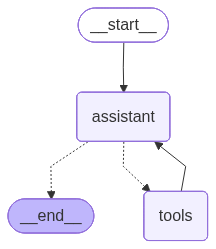

In [53]:
##print(baseline_agent.get_graph().draw_mermaid_png())
from IPython.display import Image, display
display(Image(baseline_agent.get_graph().draw_mermaid_png()))

### Run and Inspect One Trace

We begin with a request that should need exactly one tool call. The helper keeps the full message list so we can inspect and score the same evidence.

In [50]:
def run_turn(agent, user_text: str, history: list[Any] | None = None) -> list[Any]:
    messages = [*(history or []), LCHumanMessage(content=user_text)]
    result = agent.invoke({"messages": messages})
    return result["messages"]


def show_messages(messages: list[Any]) -> None:
    for index, message in enumerate(messages, start=1):
        print(f"\n--- Message {index}: {message.type} ---")
        print(message.pretty_repr())


agent_evaluation_contract = {
    "request": "What is the live USD spot price of copper per gram?",
    "reference_tool_calls": [
        RagasToolCall(name="get_metal_price", args={"metal_name": "copper"})
    ],
    "allowed_topics": ["live metal spot prices"],
}

copper_messages = run_turn(
    baseline_agent,
    agent_evaluation_contract["request"],
)
show_messages(copper_messages)


--- Message 1: human ---
================================ Human Message =================================

What is the live USD spot price of copper per gram?

--- Message 2: ai ---
================================== Ai Message ==================================
Tool Calls:
  get_metal_price (call_d084jaZ0p3IwGoI5lzRQbGuc)
 Call ID: call_d084jaZ0p3IwGoI5lzRQbGuc
  Args:
    metal_name: copper

--- Message 3: tool ---
================================= Tool Message =================================
Name: get_metal_price

{"currency": "USD", "metal": "copper", "price_usd_per_gram": 0.0137, "timestamp": null, "unit": "g"}

--- Message 4: ai ---
================================== Ai Message ==================================

Live copper spot price: **$0.0137 USD per gram**.

This is live market data for informational purposes, not financial advice.


## Task 10: Normalize a LangGraph Trace for Ragas

Ragas evaluates its own message schema. Instead of depending on provider-specific raw payloads, this adapter uses LangChain's normalized <code>AIMessage.tool_calls</code> field. That makes the evaluation layer more stable when model providers or SDK response shapes change.

System messages guide the run but are intentionally excluded from the trace under evaluation.

In [51]:
def content_as_text(content: Any) -> str:
    if isinstance(content, str):
        return content
    return json.dumps(content, ensure_ascii=False, default=str)


def to_ragas_messages(messages: list[Any]) -> list[Any]:
    converted = []

    for message in messages:
        if isinstance(message, LCHumanMessage):
            converted.append(RagasHumanMessage(content=content_as_text(message.content)))
        elif isinstance(message, LCAIMessage):
            tool_calls = [
                RagasToolCall(
                    name=tool_call["name"],
                    args=dict(tool_call.get("args") or {}),
                )
                for tool_call in message.tool_calls
            ]
            converted.append(
                RagasAIMessage(
                    content=content_as_text(message.content),
                    tool_calls=tool_calls or None,
                )
            )
        elif isinstance(message, LCToolMessage):
            converted.append(RagasToolMessage(content=content_as_text(message.content)))
        elif isinstance(message, LCSystemMessage):
            continue
        else:
            raise TypeError(f"Unsupported LangChain message: {type(message).__name__}")

    return converted


copper_trace = to_ragas_messages(copper_messages)
for index, message in enumerate(copper_trace, start=1):
    print(f"\n--- Ragas message {index}: {message.type} ---")
    print(message.pretty_repr())


--- Ragas message 1: human ---
Human: What is the live USD spot price of copper per gram?

--- Ragas message 2: ai ---
Tools:
  get_metal_price: {'metal_name': 'copper'}

--- Ragas message 3: tool ---
ToolOutput: {"currency": "USD", "metal": "copper", "price_usd_per_gram": 0.0137, "timestamp": null, "unit": "g"}

--- Ragas message 4: ai ---
AI: Live copper spot price: **$0.0137 USD per gram**.

This is live market data for informational purposes, not financial advice.


#### Question #5

Why is it useful to score the same normalized trace that you inspect manually, rather than logging one representation and evaluating a different one?

##### 
You don't want the original AI/TOOL/HUMAN message of the Agent to be massaged in anyway such that the key points in the message goes amiss or replaced as that is going to result in a wong evaluation from judge LLM. So you should send the exact trace normalized to RAGAS.




## Task 11: Evaluate Agent Performance with Ragas Metrics

Different metrics answer different questions. A high final-answer score does not prove that the agent followed the desired process, and a correct tool call does not prove that the application stayed in scope.

### Tool-Call Accuracy

<code>ToolCallAccuracy</code> is a deterministic process metric. It checks the tool-call sequence and arguments against a reference. Here we expect precisely one call to <code>get_metal_price</code> with <code>metal_name="copper"</code>.

The modern Ragas collection API returns a <code>MetricResult</code>; its <code>value</code> is between 0 and 1.

In [55]:
async def score_tool_call_accuracy():
    return await ToolCallAccuracy(strict_order=True).ascore(
        user_input=copper_trace,
        reference_tool_calls=agent_evaluation_contract["reference_tool_calls"],
    )


tool_call_result = run_ragas_async(score_tool_call_accuracy)

print(f"Tool-call accuracy: {tool_call_result.value:.2f}")

Tool-call accuracy: 1.00


A score below 1 is not automatically a model failure. Inspect the trace first. Common causes include a misspelled metal, a missing tool call, an extra tool call, or an otherwise reasonable choice whose argument does not match the test's expected contract.

### Agent Goal Accuracy

Tool-call accuracy measures the process. <code>AgentGoalAccuracyWithReference</code> asks an LLM judge whether the final workflow outcome meets a stated reference. This is useful when multiple valid tool paths could satisfy the user.

Unlike the previous metric, goal accuracy is LLM-based. It makes structured judge calls through AI Gateway, so treat it as a useful signal to inspect—not a source of unquestionable truth.

In [62]:
silver_messages = run_turn(
    baseline_agent,
    "What is the live USD spot price of 10 grams of silver?",
)
silver_trace = to_ragas_messages(silver_messages)

async def score_goal_accuracy():
    return await AgentGoalAccuracyWithReference(
        llm=build_sync_judge_llm()
    ).ascore(
        user_input=silver_trace,
        reference=(
            "Report the current USD spot price for 10 grams of silver using the "
            "live tool result, including a clear informational-not-advice boundary."
        ),
    )


goal_result = run_ragas_async(score_goal_accuracy)

show_messages(silver_messages)
print(f"Agent-goal accuracy: {goal_result.value:.2f}")


--- Message 1: human ---
================================ Human Message =================================

What is the live USD spot price of 10 grams of silver?

--- Message 2: ai ---
================================== Ai Message ==================================
Tool Calls:
  get_metal_price (call_kuvECrxCNBnu9D6OdRZtCmA8)
 Call ID: call_kuvECrxCNBnu9D6OdRZtCmA8
  Args:
    metal_name: silver

--- Message 3: tool ---
================================= Tool Message =================================
Name: get_metal_price

{"currency": "USD", "metal": "silver", "price_usd_per_gram": 1.9018, "timestamp": null, "unit": "g"}

--- Message 4: ai ---
================================== Ai Message ==================================

Live silver spot price: **$1.9018 USD per gram**

So for **10 grams**, that’s **$19.018 USD**.

Informational only, not financial advice.
Agent-goal accuracy: 0.00


#### Question #6

Give one example in which tool-call accuracy could be 1.0 while agent-goal accuracy is low. Give another in which goal accuracy could be high while the exact expected tool call was not used.

##### Answer

In the above example for 10g of silver, agent-goal-accuracy is 0 while tool-call accuracy is 1. Turns out that the RAGAS LLM to answer to the point. Here the agent gave price / gram and then gave price per 10g which and this 10g price the LLM judge didn't like and gave agent goal accuracy a 0! If the agent had assigned the live price in one sentence for 10g os silver it wont be a problem and agent goal accuracy would be a 1. The LLM thought that the price per gram is the live price and that the agent hallucinated on the 10g price!

About the second part of question, when you have multiple tools and RAGAS Was asked to expect only a subset of these tools to evaluate the agent against. However, the agent delivered the right goal while using a tool that was not registered with RAGAS. So agent goal accuracy w0uld be a 1, tool accuracy would be a 0

### Topic Adherence and a Scope Guardrail

A narrow tool does not, by itself, keep a general-purpose language model from answering unrelated questions. We will compare two otherwise identical agents on a two-turn transcript:

1. An in-scope copper-price request.
2. An unrelated question about eagle flight speed.

The baseline is allowed to be generally helpful; the guarded version should decline the unrelated request. We use **precision** mode because it asks: of the topics the agent actually answered, how many were inside the approved live-metal-price scope?

In [70]:
def run_scope_case(agent) -> list[Any]:
    history = run_turn(
        agent,
        "What is the live USD spot price of copper per gram?",
    )
    return run_turn(agent, "is the price of copper per gram expensive?", history=history)

baseline_scope_messages = run_scope_case(baseline_agent)
guarded_scope_messages = run_scope_case(guarded_agent)

baseline_scope_trace = to_ragas_messages(baseline_scope_messages)
guarded_scope_trace = to_ragas_messages(guarded_scope_messages)

async def score_topic_adherence(trace):
    topic_metric = TopicAdherence(
        llm=build_sync_judge_llm(),
        mode="precision",
    )
    return await topic_metric.ascore(
        user_input=trace,
        reference_topics=agent_evaluation_contract["allowed_topics"],
    )


baseline_topic_result = run_ragas_async(
    score_topic_adherence,
    baseline_scope_trace,
)
guarded_topic_result = run_ragas_async(
    score_topic_adherence,
    guarded_scope_trace,
)

print(f"Baseline topic-adherence precision: {baseline_topic_result.value:.2f}")
print(f"Guarded topic-adherence precision: {guarded_topic_result.value:.2f}")

print("\nBaseline trace:")
show_messages(baseline_scope_messages)
print("\nGuarded trace:")
show_messages(guarded_scope_messages)

Baseline topic-adherence precision: 0.33
Guarded topic-adherence precision: 0.00

Baseline trace:

--- Message 1: human ---
================================ Human Message =================================

What is the live USD spot price of copper per gram?

--- Message 2: ai ---
================================== Ai Message ==================================
Tool Calls:
  get_metal_price (call_dgL8ZeRz2ZMdLiCMRpqtBOI4)
 Call ID: call_dgL8ZeRz2ZMdLiCMRpqtBOI4
  Args:
    metal_name: copper

--- Message 3: tool ---
================================= Tool Message =================================
Name: get_metal_price

{"currency": "USD", "metal": "copper", "price_usd_per_gram": 0.0137, "timestamp": null, "unit": "g"}

--- Message 4: ai ---
================================== Ai Message ==================================

Live copper spot price: **$0.0137 USD per gram**.

This is live market data for informational purposes only, not financial advice.

--- Message 5: human ---
=============

The comparison is deliberately small, not a production scorecard. If the guarded score does not improve, inspect the messages before changing the metric: perhaps the model answered the unrelated question anyway, the refusal was ambiguous, or the judge classified a topic differently from your product definition.

#### Question #7

Why is a higher topic-adherence score not enough by itself to prove that a production agent is safe or useful? Name at least two kinds of evidence you would add.

##### Answer

higher topic adherence score is judged by a LLM. With my expriements above I see that if there is a response from an agent about a topic that is even slightly verbose , the llm judge grades this agent poorly even thogh agent did the right thing. Seems like the judge can only grade very crisp asnwers correctly. BIG LIMITATION. 

2 kinds of evidence to prove the lack of trustworthiness of topic-adherence by itself 
a) Let's say that your agent wants to know the price of bronze which is an alloy but not a metal per se. I simulated 2 turns with 2nd query to get price of bronze. Both the agents couldn't pull up a price as both detected bronze is an alloy. But agent topic adherence was 0.33 for baseline agent and 1 for guarded agent. It should have been 1 for both. I guess LLM judge thinks that the baseline LLM is trying to pull up price for the alloy and hence deviating from the topic, but the baseline agent did not deviate but only asked for a valid query even though its response was verbose as above.  I am shocked at the grading of LLM judge. It seems like you can't have a verbose response even if it's correct and expect the LLM judge to evaluate you correctly! 


b) I simulated a 2 turn run for baseline/gaurded agents where the query for the second turn is "Is the price of copper expensive?". The scroes for topic precision was 0.3 for baseline and 0 for guarded agent as above. Both the agents were talking about metal prices and I don't see how how the scores add up. But it seems like the query itself has to be crisp and specific, not something like generating an opinnion.  So for scenarios where the LLM Judge is asked to grade a subjective response for an open ended question (as above), LLM can judge horribly 



## Activity #2: Add a Tool-Call Regression Case

Create a new test case for a supported metal. Keep the request unambiguous enough that you can state the expected tool call precisely.

Requirements:

1. Choose a new supported metal, such as platinum or palladium.
2. Run the baseline agent and inspect the trace.
3. Convert the trace with <code>to_ragas_messages</code>.
4. Define the matching <code>RagasToolCall</code>.
5. Score it with strict-order <code>ToolCallAccuracy</code>.
6. Record what you would expect to change if the tool schema gained a second required argument.

pt. 1 - 5 code below!!!!!!!

ANSWER for pt. 6 
If the tool gets two arguments instead of one, you'd need to change the prompts for the agents to factor in the second arguemnts in addition to the tool node itself, the evaluation contract.
I'd expect the tool call accuracy to not change. But the topic adherence precision would get more flaky and less trust worthy.

In [73]:
# YOUR CODE HERE
#
agent_evaluation_contract = {
    "request": "What is the live USD spot price of palladium per gram?",
    "reference_tool_calls": [
        RagasToolCall(name="get_metal_price", args={"metal_name": "palladium"})
    ],
    "allowed_topics": ["live metal spot prices"],
}

palladium_messages = run_turn(
    baseline_agent,
    agent_evaluation_contract["request"],
)

show_messages(palladium_messages)

palladium_trace = to_ragas_messages(palladium_messages)
for index, message in enumerate(palladium_trace, start=1):
    print(f"\n--- Ragas message {index}: {message.type} ---")
    print(message.pretty_repr())


#palladium_messages = run_turn(
#    baseline_agent,
#    "What is the live USD spot price of 10 grams of palladium?",
#)
# regression_messages = run_turn(baseline_agent, "...")
# regression_trace = to_ragas_messages(regression_messages)

async def score_regression():
     return await ToolCallAccuracy(strict_order=True).ascore(
         user_input=palladium_trace,
         reference_tool_calls = agent_evaluation_contract["reference_tool_calls"],

     )
#
regression_result = run_ragas_async(score_regression)
print(regression_result.value)


--- Message 1: human ---
================================ Human Message =================================

What is the live USD spot price of palladium per gram?

--- Message 2: ai ---
================================== Ai Message ==================================
Tool Calls:
  get_metal_price (call_v5QLf7ZWsp5jcxhKpExVtiQa)
 Call ID: call_v5QLf7ZWsp5jcxhKpExVtiQa
  Args:
    metal_name: palladium

--- Message 3: tool ---
================================= Tool Message =================================
Name: get_metal_price

{"currency": "USD", "metal": "palladium", "price_usd_per_gram": 38.7932, "timestamp": null, "unit": "g"}

--- Message 4: ai ---
================================== Ai Message ==================================

The live USD spot price of **palladium** is **$38.7932 per gram**.

This is live market data for informational purposes only, not financial advice.

--- Ragas message 1: human ---
Human: What is the live USD spot price of palladium per gram?

--- Ragas messa

### Activity #2 Notes

- Request:  
--- Message 1: human ---
================================ Human Message ======================
 What is the live USD spot price of palladium per gram?


- Expected tool call: 
================================= Tool Message =================================
Name: get_metal_price
{"currency": "USD", "metal": "palladium", "price_usd_per_gram": 38.7932, "timestamp": null, "unit": "g"}

- Score:  1.0 

- Trace evidence:  Checked
- If the tool schema changed: If the tool gets two arguments instead of one, you'd need to change the prompts for the agents to factor in the second arguemnts in addition to the tool node itself and the evaluation contract. I'd expect the tool call accuracy to not change, but the topic adherence precision would get more flaky and less trust worthy as it was already flaky with just one argument :(


## Activity #3: Design a Scope-Safety Regression

Choose an out-of-scope request that a broadly helpful model might answer, then turn it into a comparison between the baseline and guarded agents. Avoid requests for real financial advice; the point is to test the product boundary, not to solicit advice.

Requirements:

1. State the intended product boundary in one sentence.
2. Write an in-scope turn and an out-of-scope turn.
3. Run both agents with the same two-turn transcript.
4. Measure topic-adherence precision with the same approved topic list.
5. Inspect both traces.
6. Decide whether the guardrail improved the behavior for the reason you expected.
7. Note one way that an overly strict guardrail could harm user experience.

In [77]:
def run_scope_case(agent):
     history = run_turn(agent, "price of silver per gram")
     return run_turn(agent, "what is the use of 401k", history=history)
#
baseline_messages = run_scope_case(baseline_agent)
guarded_messages = run_scope_case(guarded_agent)


baseline_scope_trace = to_ragas_messages(baseline_messages)
guarded_scope_trace = to_ragas_messages(guarded_messages)

async def score_topic_adherence(trace):
    topic_metric = TopicAdherence(
        llm=build_sync_judge_llm(),
        mode="precision",
    )
    return await topic_metric.ascore(
        user_input=trace,
        reference_topics=agent_evaluation_contract["allowed_topics"],
    )


baseline_topic_result = run_ragas_async(
    score_topic_adherence,
    baseline_scope_trace,
)
guarded_topic_result = run_ragas_async(
    score_topic_adherence,
    guarded_scope_trace,
)

print(f"Baseline topic-adherence precision: {baseline_topic_result.value:.2f}")
print(f"Guarded topic-adherence precision: {guarded_topic_result.value:.2f}")

print("\nBaseline trace:")
show_messages(baseline_messages)
print("\nGuarded trace:")
show_messages(guarded_messages)


Baseline topic-adherence precision: 0.25
Guarded topic-adherence precision: 0.00

Baseline trace:

--- Message 1: human ---
================================ Human Message =================================

price of silver per gram

--- Message 2: ai ---
================================== Ai Message ==================================
Tool Calls:
  get_metal_price (call_gKNgtlJC5wrslKt5hTyouyWd)
 Call ID: call_gKNgtlJC5wrslKt5hTyouyWd
  Args:
    metal_name: silver

--- Message 3: tool ---
================================= Tool Message =================================
Name: get_metal_price

{"currency": "USD", "metal": "silver", "price_usd_per_gram": 1.9018, "timestamp": null, "unit": "g"}

--- Message 4: ai ---
================================== Ai Message ==================================

Silver is **$1.9018 USD per gram**.

This is live market data and **for informational purposes only, not financial advice**.

--- Message 5: human ---
================================ Human Message

### Activity #3 Notes

- Product boundary: answer live metal price questions.

- In-scope request:  price of a gram of silver in USD

- Out-of-scope request: what is the use of 401k?

- Baseline score and trace evidence: 0.25 , tracker shows baseline answered question about silver price and various topics related to 401k (which were out of scope)

- Guarded score and trace evidence:  0.0, the trace evidence showed that guarded agent gave answer for silver price , but then for 401k stated that it can only predict metal price. The 
  topic adherence metric was 0.0 as the judgel LLM probably thought the guarded agaent evaded a topic that is approved as it does give any specific answer.

- Did the guardrail help for the expected reason?:  Yes it does. The 401k questions went unanswered! 

- Potential user-experience cost of the guardrail: If the guardrail is worded in a fashion that makes LLM too guarded, then slightly off beat queries even though in scope would make the agent generate  a response saying it is not allowed to generate an anwer. 


## Advanced Build: Make Evaluation a Repeatable Regression Suite

Move the examples out of notebook cells and into a small versioned dataset, for example JSONL with fields for <code>name</code>, <code>messages</code>, <code>reference_tool_calls</code>, <code>reference_goal</code>, and <code>allowed_topics</code>.

Then write a runner that:

1. Executes each case against a named model and prompt version.
2. Saves the normalized trace and metric values.
3. Fails a CI check only on thresholds you have reviewed deliberately.
4. Reports cost and latency beside quality scores.
5. Keeps a small hand-reviewed set of difficult, realistic failures.

Treat the suite as a living product contract. Add a case whenever a real failure teaches you something, and retire cases only with an explicit reason.

## Final Takeaways

- A trace makes agent behavior inspectable.
- Tool-call accuracy checks an expected process; goal accuracy checks an outcome.
- Topic adherence reveals whether a product boundary is actually reflected in behavior.
- A metric becomes useful when it is paired with trace inspection, a concrete hypothesis, and a controlled change.
- AI Gateway lets the agent and the judges share one provider-agnostic integration point.